In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
import os
import glob
import pandas as pd
from datetime import datetime

import torch
import torch.optim as optim

In [2]:
def process_image(img_path):
    image = plt.imread(img_path).astype(np.float32)

    # segmentation through hsv
    image = image[:, :, :3]
    
    if image.max() > 1:
        image = image / 255.0
    
    from matplotlib.colors import rgb_to_hsv
    hsv = rgb_to_hsv(image)
    
    V = hsv[:,:,2]
    S = hsv[:,:,1]
    cloud_mask = np.zeros(V.shape, dtype=np.uint8)
    cloud_mask[(V > 0.8) & (S < 0.2)] = 255
    
    image_uint8 = (image * 255).astype(np.uint8)
    cleaned_image = cv.inpaint(image_uint8, cloud_mask, 3, cv.INPAINT_TELEA)
    
    hsv2 = rgb_to_hsv(cleaned_image / 255.0)
    
    H = hsv2[:,:,0]
    S2 = hsv2[:,:,1]
    
    segmented_hsv = np.zeros(H.shape, dtype=np.uint8) 
    segmented_hsv[(H > 0.50) & (H < 0.72) & (S2 > 0.1)] = 255

    # get info
    num_labels, labels, stats, centroids = cv.connectedComponentsWithStats(segmented_hsv, connectivity=8)
    min_area = 2000 
    output_mask = np.zeros_like(segmented_hsv)

    # eliminate small areas
    for i in range(1, num_labels):
        area = stats[i, cv.CC_STAT_AREA]
        
        if area >= min_area:
            output_mask[labels == i] = 255

    # 1 for segmentation and 0 for background
    binary = (output_mask == 255).astype(np.int32)

    #get border pixels
    border_pixels = cv.findContours(output_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_TC89_L1)[0][0].squeeze()[:,[1,0]]
    
    return binary, border_pixels

In [4]:
def process_mask(mask_path):
    binary = plt.imread(mask_path)

    #get border pixels
    border_pixels = cv.findContours(output_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_TC89_L1)[0][0].squeeze()[:,[1,0]]
    
    return binary, border_pixels

In [ ]:
from pathlib import Path

input_folder = "data/Water Quality NOVO/water_quality_masks"

# get masks filenames from input_folder

# cycle through all files ending in .png in input_folder
mask_paths = sorted(
    str(mask_file)
    for mask_file in Path(input_folder).glob("*.png")
)
    
df_excel = pd.read_excel('data/excel/AlbufeirasMaranhao_18-07-2025.xlsx')



['data/Water Quality NOVO/water_quality_masks/20150715T113023Z_cc1.2pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20150725T113026Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20150804T113028Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20151112T113021Z_cc4.4pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160311T113024Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160430T113033Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160520T113031Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160619T113030Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160629T113027Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160709T113032Z_cc0.0pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_masks/20160719T113033Z_cc2.3pct_bands.tif.png', 'data/Water Quality NOVO/water_quality_mas

In [3]:
# get images from folder
input_folder = "data/Final Attempt/sentinelhub/NDWI Maranhão"
image_extensions = ["*.png", "*.jpg", "*.jpeg"]

results = []
files = []

for ext in image_extensions:
    files.extend(glob.glob(os.path.join(input_folder, ext)))

for img_path in sorted(files):
    filename = os.path.basename(img_path)
    name = f"{filename[5]}{filename[6]}{filename[7]}{filename[8]}-{filename[9]}{filename[10]}-{filename[11]}{filename[12]}"
    cloud_per = f"{filename[24:]}"
    results.append((img_path, name, cloud_per))   

# get info from images and excel
df_images = pd.DataFrame(results)

df_excel = pd.read_excel('data/excel/AlbufeirasMaranhao_18-07-2025.xlsx')

path_img = df_images[0]
date_img = df_images[1]
cloud_img = df_images[2]
cloud_values = cloud_img.str.replace('pct.png', '', regex=False).astype(float)

date_excel = df_excel["Data"][1:].tolist()
height_excel = df_excel["Cota(m)"][1:].tolist()

# function to get from string to datetime
def to_dt(s):
    return datetime.strptime(s[:10], "%Y-%m-%d")

# relate the quota with the date
result_list = []

for i in range(len(date_img)):
    if cloud_values[i] < 10:
        img_dt = to_dt(str(date_img[i]))
        #variable to get the closest date
        best_j = -1
        min_diff = float('inf') 
        
        for j in range(len(date_excel)):
            excel_dt = to_dt(str(date_excel[j]))
            diff = abs((img_dt - excel_dt).total_seconds())
            if diff < min_diff:
                min_diff = diff
                best_j = j

        if best_j != -1 and min_diff <= (3 * 86400): 
            if date_img[i] != '2018-08-28' and date_img[i] != '2024-10-30' and date_img[i] != '2018-08-03' and date_img[i] != '2022-04-29': # outliers
                res_date = str(date_img[i])[:10]
                result_list.append([path_img[i], height_excel[best_j], cloud_img[i]])

# convert list to array
result_array = np.array(result_list, dtype=object)

In [ ]:
# all_border_pixels = []
# accumulation = 0

# for i, (path, quota, cloud) in enumerate(result_array):
#     binary, border_pixels = process_image(path)
#     accumulation += binary

#     quota_col = np.full((len(border_pixels), 1), quota)
    
#     # Capture accumulation values at this point in time, for this image's border pixels
#     y = border_pixels[:, 0].astype(int)
#     x = border_pixels[:, 1].astype(int)
#     accumulation_values = accumulation[y, x].reshape(-1, 1)

#     pixels_with_quota = np.hstack([border_pixels.astype(np.float64), quota_col, accumulation_values])
#     all_border_pixels.append(pixels_with_quota)

# all_border_pixels = np.vstack(all_border_pixels)  # shape (N, 4) -> [y, x, quota, accumulation]

all_border_pixels = []
accumulation = 0

for path, quota, cloud in result_array:
    binary, border_pixels = process_mask(path)

    accumulation += binary

    # Ensure integer indexing once
    border_pixels = border_pixels.astype(np.int32, copy=False)

    y = border_pixels[:, 0]
    x = border_pixels[:, 1]

    # Build final array directly
    pixels_with_quota = np.empty((len(border_pixels), 4), dtype=np.float64)

    pixels_with_quota[:, 0:2] = border_pixels
    pixels_with_quota[:, 2] = quota
    pixels_with_quota[:, 3] = accumulation[y, x]

    all_border_pixels.append(pixels_with_quota)

all_border_pixels = np.concatenate(all_border_pixels, axis=0)

(-0.5, 2065.5, 2068.5, -0.5)

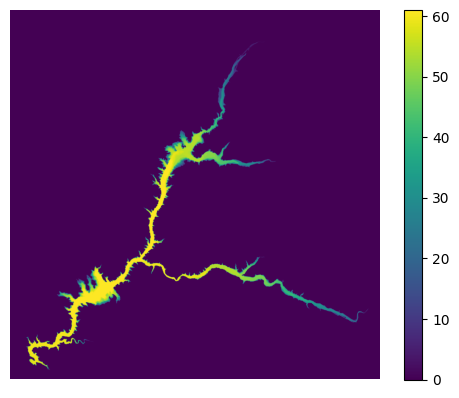

In [5]:
# plot accumulation map
plt.figure()
plt.imshow(accumulation)
plt.colorbar()
plt.axis("off")

## Terrain Reconstruction via PyTorch Optimization

We represent the terrain as a learnable 2D tensor **Z** of shape `(H, W)` matching the satellite image resolution.

The optimization minimizes the following energy functional:

$$E(Z) = \underbrace{\frac{1}{N}\sum_{i=1}^{N}\left(Z[y_i, x_i] - h_i\right)^2}_{\text{Contour Consistency}} + \lambda_{\text{TV}} \cdot \underbrace{\left(\overline{|Z_{\text{dy}}|} + \overline{|Z_{\text{dx}}|}\right)}_{\text{Total Variation}}$$

- **Contour consistency**: at every segmentation boundary pixel `(y_i, x_i)` the reconstructed elevation must match the measured water-surface height `h_i` (from `height_excel`).
- **Total variation regularization**: penalizes large elevation gradients between adjacent pixels, producing a smooth surface wherever no direct observation is available.

In [6]:
def total_variation(Z):
    """Anisotropic total variation: mean of absolute differences between neighbouring pixels."""
    diff_y = torch.abs(Z[1:, :] - Z[:-1, :])   # vertical neighbours
    diff_x = torch.abs(Z[:, 1:] - Z[:, :-1])   # horizontal neighbours
    return torch.mean(diff_y) + torch.mean(diff_x)

In [7]:
def reconstruct_terrain(
    H, W,
    border_ys, border_xs, border_heights,
    lambda_tv=5.0,
    n_iters=3000,
    lr=0.5,
    device=None,
    verbose=True,
    log_interval=500,
):
    """
    Reconstruct a dense Digital Elevation Model (DEM) from contour observations
    using PyTorch gradient descent.

    The terrain Z (shape H x W) is optimized to minimise:

        E(Z) = L_contour(Z) + lambda_tv * L_tv(Z)

    where:
        L_contour  = mean((Z[y_i, x_i] - h_i)^2)   contour consistency
        L_tv       = anisotropic total variation      smoothness regularizer

    Parameters
    ----------
    H, W : int
        Height and width of the terrain grid (must match satellite image resolution).
    border_ys : array-like, shape (N,)
        Row indices of all segmentation boundary pixels across all images.
    border_xs : array-like, shape (N,)
        Column indices of all segmentation boundary pixels across all images.
    border_heights : array-like, shape (N,)
        Known real-world elevation at each boundary pixel (from Excel measurements).
    lambda_tv : float
        Weight for the total variation regularization term.
    n_iters : int
        Number of gradient descent iterations.
    lr : float
        Learning rate for the Adam optimizer.
    device : str or torch.device, optional
        Compute device ('cpu' or 'cuda'). Auto-detected if None.
    verbose : bool
        If True, print loss every `log_interval` iterations.
    log_interval : int
        Logging frequency (in iterations).

    Returns
    -------
    Z_np : np.ndarray, shape (H, W)
        Reconstructed elevation map in metres.
    loss_history : list of dict
        Per-logged-iteration dict with keys 'iter', 'loss', 'L_contour', 'L_tv'.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    print(f"Device : {device}")
    print(f"Grid   : {H} x {W}  ({H*W:,} pixels)")
    print(f"Obs    : {len(border_ys):,} boundary pixels")
    print(f"lambda_tv={lambda_tv}, lr={lr}, n_iters={n_iters}")
    print("-" * 60)

    # ── Initialise learnable terrain ──────────────────────────────────
    # Start from the mean observed height so the optimiser has a warm start.
    h_mean = float(np.mean(border_heights))
    Z = torch.full((H, W), h_mean, dtype=torch.float32, device=device, requires_grad=True)

    optimizer = optim.Adam([Z], lr=lr)

    # ── Observation tensors ───────────────────────────────────────────
    ys      = torch.tensor(border_ys,      dtype=torch.long,    device=device)
    xs      = torch.tensor(border_xs,      dtype=torch.long,    device=device)
    heights = torch.tensor(border_heights, dtype=torch.float32, device=device)

    loss_history = []

    # ── Optimisation loop ─────────────────────────────────────────────
    for it in range(n_iters):
        optimizer.zero_grad()

        # 1) Contour consistency: minimise squared error at boundary pixels
        z_at_contour = Z[ys, xs]
        L_contour = torch.mean((z_at_contour - heights) ** 2)

        # 2) Total variation: penalise large local elevation gradients
        L_tv = total_variation(Z)

        # 3) Total energy
        loss = L_contour + lambda_tv * L_tv

        loss.backward()
        optimizer.step()

        if verbose and (it % log_interval == 0 or it == n_iters - 1):
            entry = {
                "iter":      it,
                "loss":      loss.item(),
                "L_contour": L_contour.item(),
                "L_tv":      L_tv.item(),
            }
            loss_history.append(entry)
            print(
                f"  iter {it:5d}/{n_iters-1}  "
                f"loss={entry['loss']:.4f}  "
                f"L_contour={entry['L_contour']:.4f}  "
                f"L_tv={entry['L_tv']:.4f}"
            )

    Z_np = Z.detach().cpu().numpy()
    return Z_np, loss_history

In [8]:
# ── Extract observations from the accumulated border-pixel table ──────
# all_border_pixels columns: [y, x, quota (m), accumulation_count]
border_ys      = all_border_pixels[:, 0].astype(int)
border_xs      = all_border_pixels[:, 1].astype(int)
border_heights = all_border_pixels[:, 2].astype(np.float32)   # real elevation (m)

# Grid dimensions from accumulation map (matches all satellite images)
H, W = accumulation.shape

print(f"Grid size            : {H} x {W}")
print(f"Total observations   : {len(border_ys):,}")
print(f"Elevation range      : [{border_heights.min():.2f}, {border_heights.max():.2f}] m")

# ── Run terrain reconstruction ────────────────────────────────────────
DEM, loss_history = reconstruct_terrain(
    H=H, W=W,
    border_ys=border_ys,
    border_xs=border_xs,
    border_heights=border_heights,
    lambda_tv=5.0,      # increase to enforce stronger smoothness
    n_iters=3000,
    lr=0.5,
    verbose=True,
    log_interval=500,
)

Grid size            : 2069 x 2066
Total observations   : 180,633
Elevation range      : [113.40, 130.00] m
Device : cpu
Grid   : 2069 x 2066  (4,274,554 pixels)
Obs    : 180,633 boundary pixels
lambda_tv=5.0, lr=0.5, n_iters=3000
------------------------------------------------------------
  iter     0/2999  loss=16.2418  L_contour=16.2418  L_tv=0.0000
  iter   500/2999  loss=6.0765  L_contour=5.1871  L_tv=0.1779
  iter  1000/2999  loss=6.1531  L_contour=5.1870  L_tv=0.1932
  iter  1500/2999  loss=6.1346  L_contour=5.1869  L_tv=0.1895
  iter  2000/2999  loss=6.1131  L_contour=5.1870  L_tv=0.1852
  iter  2500/2999  loss=6.1027  L_contour=5.1871  L_tv=0.1831
  iter  2999/2999  loss=6.0974  L_contour=5.1871  L_tv=0.1821


In [12]:
np.save("DEM", DEM)

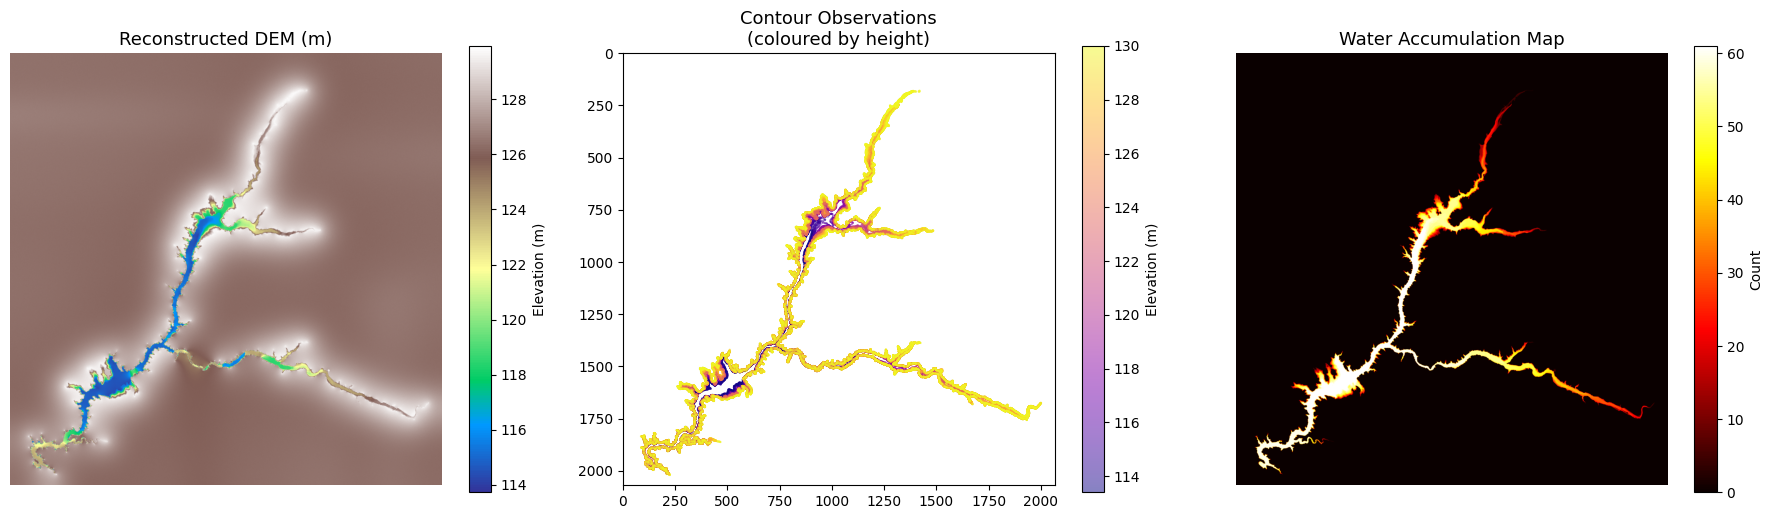

In [9]:
# ── Main visualisation: DEM | observation scatter | accumulation ──────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reconstructed DEM
im0 = axes[0].imshow(DEM, cmap="terrain")
axes[0].set_title("Reconstructed DEM (m)", fontsize=13)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="Elevation (m)")

# Contour observations coloured by height
sc = axes[1].scatter(
    border_xs, border_ys,
    c=border_heights, cmap="plasma",
    s=0.3, alpha=0.5,
)
axes[1].set_xlim(0, W)
axes[1].set_ylim(H, 0)
axes[1].set_title("Contour Observations\n(coloured by height)", fontsize=13)
axes[1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1], label="Elevation (m)")

# Water accumulation map
im2 = axes[2].imshow(accumulation, cmap="hot")
axes[2].set_title("Water Accumulation Map", fontsize=13)
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], label="Count")

plt.tight_layout()
plt.show()

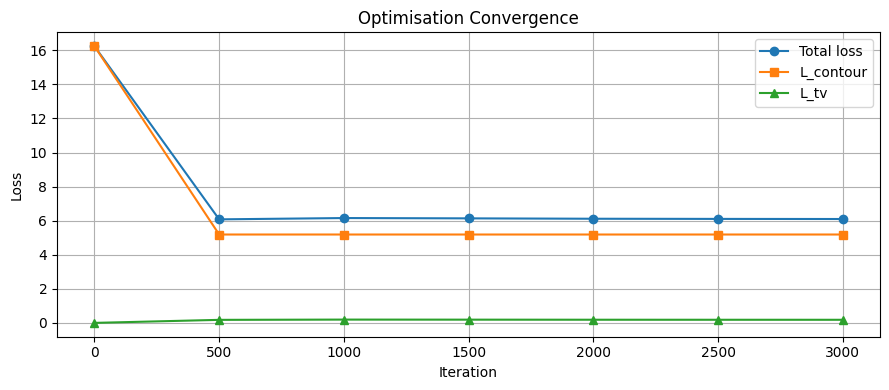

In [9]:
# ── Convergence curve ─────────────────────────────────────────────────
iters      = [e["iter"]      for e in loss_history]
total_loss = [e["loss"]      for e in loss_history]
lc_vals    = [e["L_contour"] for e in loss_history]
ltv_vals   = [e["L_tv"]      for e in loss_history]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(iters, total_loss, marker="o", label="Total loss")
ax.plot(iters, lc_vals,    marker="s", label="L_contour")
ax.plot(iters, ltv_vals,   marker="^", label="L_tv")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Optimisation Convergence")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

DEM shape  : (2069, 2066)
Min elev.  : 113.697 m
Max elev.  : 129.968 m
Mean elev. : 126.497 m
Std  elev. : 1.616 m

Boundary residuals:
  RMSE : 2.2775 m
  MAE  : 1.4615 m
  Max  : 13.6718 m


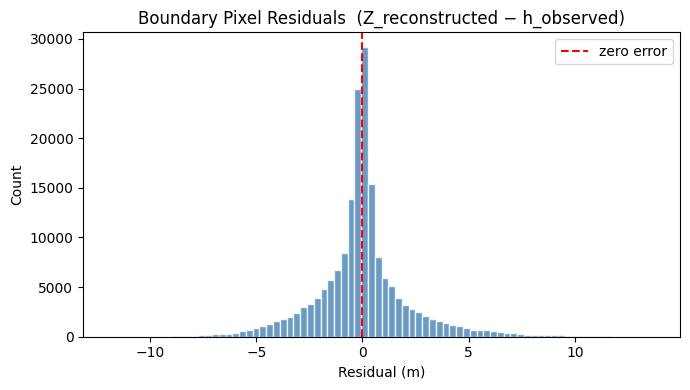

In [10]:
# ── DEM statistics ────────────────────────────────────────────────────
print(f"DEM shape  : {DEM.shape}")
print(f"Min elev.  : {DEM.min():.3f} m")
print(f"Max elev.  : {DEM.max():.3f} m")
print(f"Mean elev. : {DEM.mean():.3f} m")
print(f"Std  elev. : {DEM.std():.3f} m")

# Residuals at the constrained boundary pixels
residuals = DEM[border_ys, border_xs] - border_heights
print(f"\nBoundary residuals:")
print(f"  RMSE : {np.sqrt(np.mean(residuals**2)):.4f} m")
print(f"  MAE  : {np.mean(np.abs(residuals)):.4f} m")
print(f"  Max  : {np.max(np.abs(residuals)):.4f} m")

# Distribution of residuals
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="zero error")
plt.xlabel("Residual (m)")
plt.ylabel("Count")
plt.title("Boundary Pixel Residuals  (Z_reconstructed − h_observed)")
plt.legend()
plt.tight_layout()
plt.show()

# Estimate elevation of new image

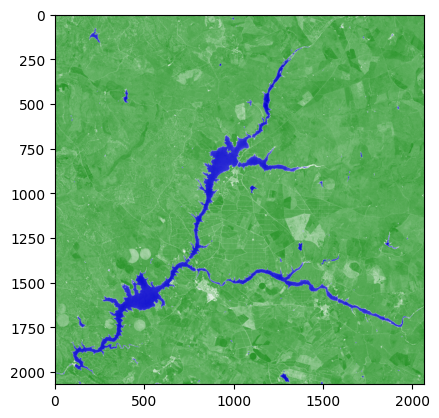

Using device: cuda
Loading SAM3 model...
Running inference with prompt: 'largest body of water'...
Found 1 object(s). Selecting the highest score mask...
Selected mask index 0 with score 0.6445
Saved binary mask to mask.png


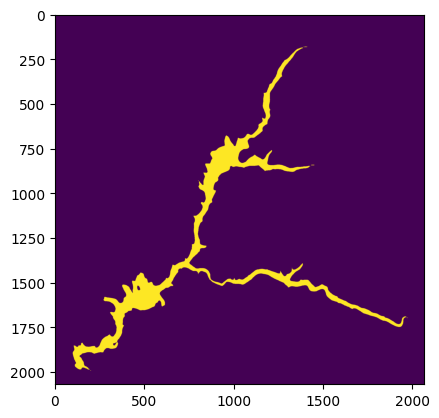

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sam3_segmentation import segment_image

img1 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20250329T113031Z_cc0.0pct.png")
#img = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20221125T113025Z_cc6.3pct.png")
#img2 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20220628T113042Z_cc0.0pct.png")
img2 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20170115T113021Z_cc0.0pct.png")

DEM = np.load("DEM.npy")
image = plt.imread(img1).astype(np.float32)
plt.imshow(image)
plt.show()

mask = segment_image(img1, prompt="largest body of water")


#mask = plt.imread('segmentation/mask.png').astype(np.float32)
plt.imshow(mask)
plt.show()

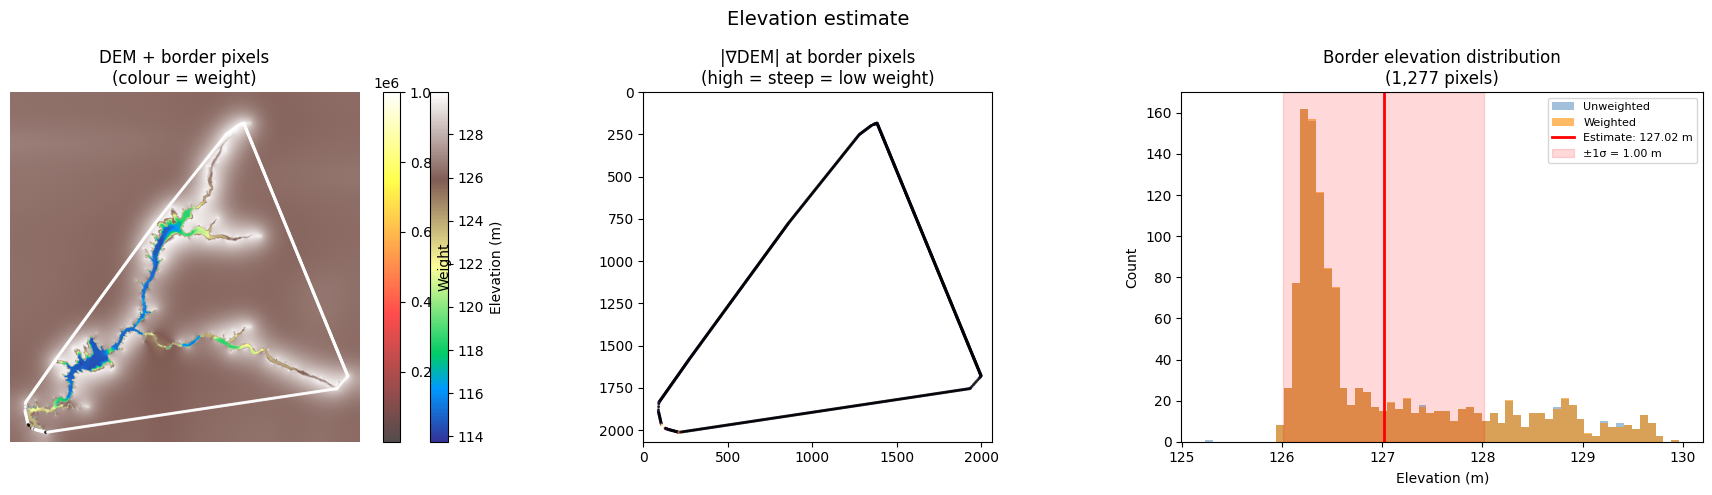

In [2]:
from estimate_elevation import estimate_elevation_from_image, plot_estimate

result = estimate_elevation_from_image(img1, DEM, return_details=True)

plot_estimate(DEM, result)

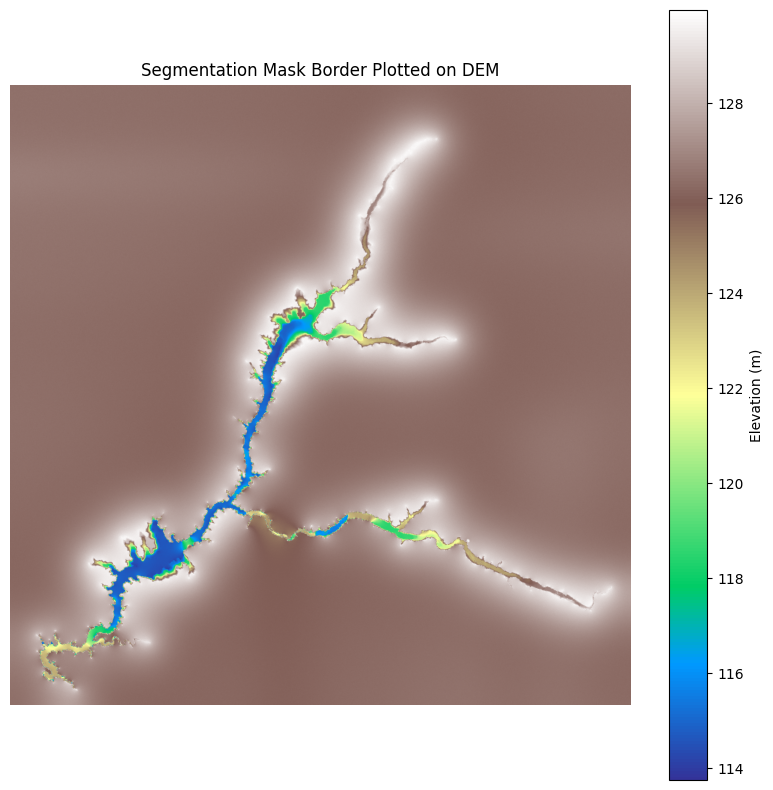

In [39]:
# Load DEM if not already loaded
if 'DEM' not in globals():
    DEM = np.load("DEM.npy")

# Ensure we have the mask and it's valid
if 'mask' in globals() and mask is not None:
    import cv2 as cv
    import matplotlib.pyplot as plt
    
    # Find contours/border from the binary segmentation mask
    binary_mask = (mask > 0).astype(np.uint8) * 255
    contours, _ = cv.findContours(binary_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    
    # Plot the border on top of the DEM
    plt.figure(figsize=(10, 10))
    plt.imshow(DEM, cmap='terrain')
    
    # Plot each contour
    border_plotted = False
    #for contour in contours:
    #    pts = contour.squeeze()
    #    if pts.ndim == 2:
    #        xs = pts[:, 0]
    #        ys = pts[:, 1]
    #        # Close the loop
    #        xs = np.append(xs, xs[0])
    #        ys = np.append(ys, ys[0])
    #        plt.plot(xs, ys, color='red', linewidth=1.5, label='Segmentation Mask Border' if not border_plotted else "")
    #        border_plotted = True
    #    elif pts.ndim == 1 and len(pts) == 2:
    #        plt.plot([pts[0]], [pts[1]], 'ro', markersize=2)
            
    plt.colorbar(label='Elevation (m)')
    plt.title('Segmentation Mask Border Plotted on DEM')
    plt.axis('off')
    if border_plotted:
        plt.legend(loc='upper right')
    plt.show()
else:
    print("Error: 'mask' variable is not defined or is None. Please run the segmentation cell first.")

In [30]:
result

{'elevation': 126.89356537680443,
 'std': 0.9075646312154145,
 'n_pixels': 1277,
 'weights_sum': 7537.12158203125,
 'details': {'border_ys': array([184, 185, 186, ..., 188, 186, 184]),
  'border_xs': array([1380, 1379, 1377, ..., 1385, 1384, 1383]),
  'elevations': array([129.6819458 , 129.62818909, 129.70240784, ..., 129.57727051,
         129.70368958, 129.96284485]),
  'weights': array([0.88270986, 1.6596078 , 3.3930645 , ..., 2.5602186 , 2.9262395 ,
         1.7176715 ], dtype=float32)},
 'seg_mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)}

In [28]:
d = result["details"]
print(d["weights"])

[0.88270986 1.6596078  3.3930645  ... 2.5602186  2.9262395  1.7176715 ]


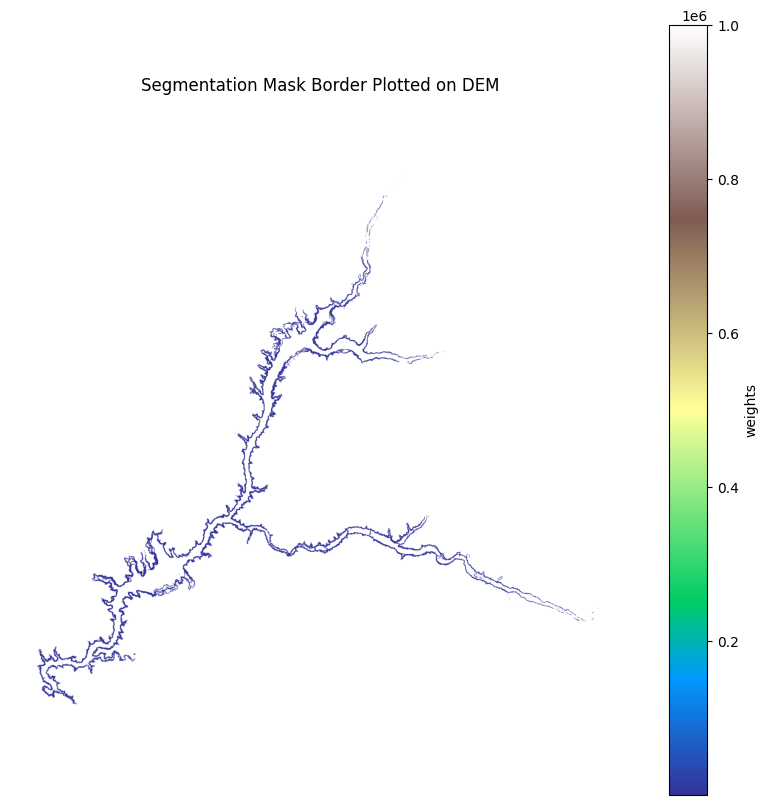

In [49]:
import cv2 as cv
import matplotlib.pyplot as plt
from estimate_elevation import _dem_gradient_magnitude

# Get pixel weights
#weights = result["details"]['weights'] only has weights of borders
gradient_magnitude = _dem_gradient_magnitude(DEM)
weights = 1.0 / ((gradient_magnitude-5).clip(min=0) + 1e-6)
#weights = np.exp(-(gradient_magnitude-2).clip(min=0))

# Plot the border on top of the DEM
plt.figure(figsize=(10, 10))
plt.imshow(weights, cmap='terrain')

""" # Plot each contour
border_plotted = False
for contour in contours:
    pts = contour.squeeze()
    if pts.ndim == 2:
        xs = pts[:, 0]
        ys = pts[:, 1]
        # Close the loop
        xs = np.append(xs, xs[0])
        ys = np.append(ys, ys[0])
        plt.plot(xs, ys, color='red', linewidth=1.5, label='Segmentation Mask Border' if not border_plotted else "")
        border_plotted = True
    elif pts.ndim == 1 and len(pts) == 2:
        plt.plot([pts[0]], [pts[1]], 'ro', markersize=2) """
        
plt.colorbar(label='weights')
plt.title('Segmentation Mask Border Plotted on DEM')
plt.axis('off')
if border_plotted:
    plt.legend(loc='upper right')
plt.show()

In [34]:
weights.min()

0.017092977